| Experimento | Descripción |
|-------------|-------------|
| **EXP1** | Degradación de la señal: ¿cómo responde la entropía de atención al ruido en la entrada? |
| **EXP2** | Sensibilidad semántica: cabezas que más distinguen texto coherente de ruido i.i.d. |
| **EXP3** | Diferenciación de estilo: cabezas que más distinguen modo wiki de modo poem |

## Requisitos
```bash
pip install -e ".[dev]"   # desde la raíz de attnspectra/
```


## 1. Imports y configuración

In [17]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
# Añadir experiments/ al path para importar gpt_model
sys.path.insert(0, str(Path.cwd().parent / "experiments"))

import numpy as np
import matplotlib.pyplot as plt
import torch
from tokenizers import Tokenizer

import attnspectra as aspec
from attnspectra import (
    CaptureConfig, CustomGPTAdapter,
    compute_head_metrics, stack_metric, top_sensitive_heads,
    make_variants, plot_attention_matrix, plot_attention_matrix_interactive,
    heatmap_delta, heatmap_metric,
    plot_delta_lines_by_condition, plot_metric_by_layer,
    save_run, save_metrics, load_run, load_metrics,
    set_seed,
)
from models.gpt_model import GPT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("attnspectra version:", aspec.__version__)
print("Device:", device)

attnspectra version: 0.1.0
Device: cpu


## 2. Carga del modelo

In [18]:
CKPT_PATH = "../checkpoints/best.pt"

ckpt      = torch.load(CKPT_PATH, map_location=device, weights_only=False)
tokenizer = Tokenizer.from_file(str(Path.cwd().parent /"tokenizer_mix_es" / "tokenizer.json"))

sid         = ckpt["special_ids"]
pad_id      = sid["pad_id"]
bos_id      = sid["bos_id"]
eos_id      = sid["eos_id"]
wiki_tok_id = sid["wiki_tok_id"]
poem_tok_id = sid["poem_tok_id"]
sep_id      = sid["sep_id"]

cfg   = ckpt["config"]
model = GPT(**cfg).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
torch.set_grad_enabled(False)

print(f"Modelo cargado | opt_step={ckpt['opt_step']}")
print(f"Métricas de validación: {ckpt.get('extra_metrics', {})}")

Modelo cargado | opt_step=25000
Métricas de validación: {'val_loss_wiki': 5.118332505226135, 'val_loss_poem': 3.3364053070545197, 'lr': 4.000000825781392e-06, 'best_on': 'wiki', 'best_metric': 5.118332505226135}


## 3. Adapter y configuración de captura

In [19]:
adapter = CustomGPTAdapter(
    model=model,
    tokenizer=tokenizer,
    n_layers=cfg["n_layers"],
    n_heads=cfg["n_heads"],
    d_model=cfg["d_model"],
    model_name="custom-gpt-es",
    device=device,
)

capture_config = CaptureConfig(
    capture_attn_pre=True,
    capture_scores=False,
    target_layers=None,   # None = todas las capas
)

PREFIX_LEN  = 3   # <bos> <style> <sep>
VOCAB_SIZE  = cfg["vocab_size"]
STYLE_WIKI  = 0
STYLE_POEM  = 1

def build_ids(text: str, style_idx: int, max_len: int = 256) -> list[int]:
    """Construye la secuencia de ids con el prefijo de estilo correcto."""
    style_token = wiki_tok_id if style_idx == STYLE_WIKI else poem_tok_id
    prefix  = [bos_id, style_token, sep_id]
    content = tokenizer.encode(text.replace("\n", " <nl> ")).ids
    ids = prefix + content
    if max_len and len(ids) > max_len:
        ids = ids[:PREFIX_LEN] + ids[-(max_len - PREFIX_LEN):]
    return ids

def capture_text(text: str, style_idx: int, max_len: int = 256):
    """Captura atención para un texto y devuelve (CapturedRun, HeadMetrics)."""
    ids        = build_ids(text, style_idx, max_len)
    input_ids  = torch.tensor([ids], dtype=torch.long)
    run        = adapter.capture_from_ids(input_ids, capture_config, style_idx=style_idx)
    metrics    = compute_head_metrics(run)
    return run, metrics

print("Adapter OK:", adapter.model_info)

Adapter OK: ModelInfo(name='custom-gpt-es', architecture='decoder', n_layers=8, n_heads=8, d_model=512, extra={})


### Visualización de una matriz de atención

seq_len=13 | tokens: ['', '', '', ' La', ' pa', 'ella', ' es', ' una', ' comida', ' típica']


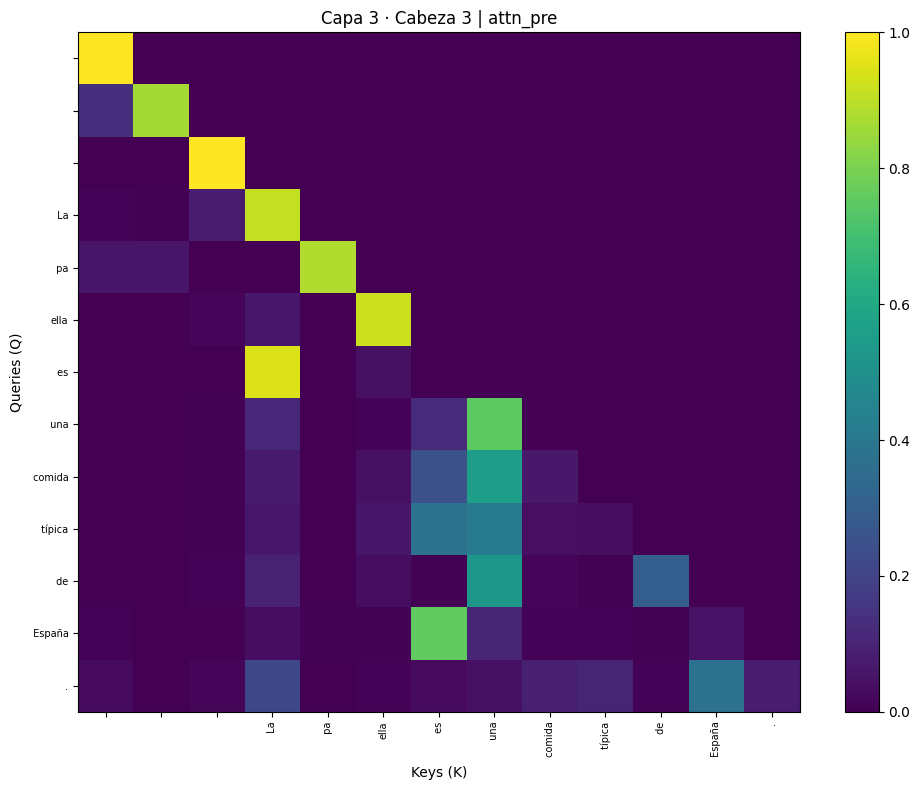

In [20]:
set_seed(42)

run_test, metrics_test = capture_text(
    "La paella es una comida típica de España.",
    style_idx=STYLE_WIKI
)

print(f"seq_len={run_test.seq_len} | tokens: {run_test.token_strs[:10]}")

# Mostrar la capa 3, cabeza 3
A = run_test.get_attention(layer=3, head=3)
fig = plot_attention_matrix(A, run_test.token_strs, max_tokens=40,
                             title="Capa 3 · Cabeza 3 | attn_pre")
plt.show()

### Visualización interactiva de todas las matrices de atención por capa y cabeza

In [21]:
fig = plot_attention_matrix_interactive(run_test)

## EXP1 — Degradación de la señal

**Hipótesis**: la entropía de atención aumenta cuando se introduce ruido en la entrada,
porque las cabezas no pueden encontrar patrones y distribuyen la atención de forma más uniforme.

**Variantes de degradación**:
- `clean`: texto original
- `shuffle`: tokens de contenido barajados aleatoriamente
- `replace_10/30/50%`: fracción de tokens reemplazados por ids aleatorios
- `random_iid`: todo el contenido reemplazado por ids uniformes i.i.d.


In [ ]:
TEXTS_EXP1 = [
    "La fotosíntesis es el proceso por el cual las plantas convierten la luz en energía química.",
    "Madrid es la capital de España y uno de los principales centros culturales del país.",
    "El aprendizaje automático utiliza datos para construir modelos que generalizan a nuevos ejemplos.",
    "La historia de España abarca múltiples periodos, desde la Antigüedad hasta la democracia.",
    "Los océanos regulan el clima global mediante corrientes y ciclos biogeoquímicos.",
]

set_seed(123)
MAX_LEN   = 256
T_FIXED   = None  # se calcula como el mínimo entre textos

# Calcular T_fixed
all_ids = [build_ids(t, STYLE_WIKI, MAX_LEN) for t in TEXTS_EXP1]
T_FIXED = min(len(ids) for ids in all_ids)
print(f"T_fixed = {T_FIXED} tokens")

per_cond: dict[str, list] = {c: [] for c in
    ["clean","shuffle","replace_10%","replace_30%","replace_50%","random_iid"]}

for t, base_ids in zip(TEXTS_EXP1, all_ids):
    # Recortar a T_fixed
    trimmed = base_ids[:PREFIX_LEN] + base_ids[-(T_FIXED - PREFIX_LEN):]
    variants = make_variants(trimmed, vocab_size=VOCAB_SIZE,
                             prefix_len=PREFIX_LEN, seed=123)
    for cond_name, vid in variants.items():
        vid_t = torch.tensor([vid], dtype=torch.long)
        vrun  = adapter.capture_from_ids(vid_t, capture_config, style_idx=STYLE_WIKI)
        per_cond[cond_name].append(compute_head_metrics(vrun))

print("EXP1 calculado.")

T_fixed = 17 tokens
EXP1 calculado.


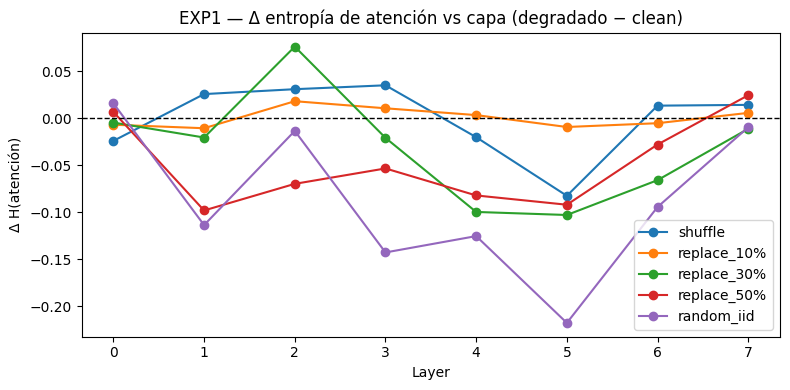

In [ ]:
#  Gráfico: Δ entropía vs capa  ─
fig = plot_delta_lines_by_condition(
    per_cond,
    metric_key="A_attn_entropy",
    base="clean",
    title="EXP1 — Δ entropía de atención vs capa (degradado − clean)",
    ylabel="Δ H(atención)",
)
plt.show()

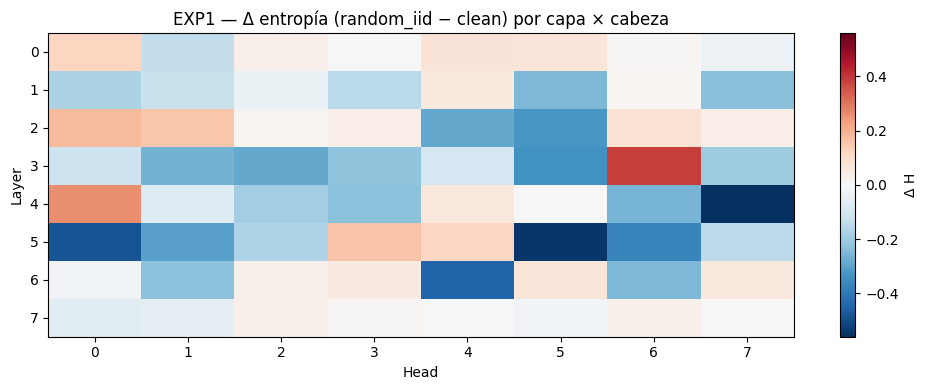

In [ ]:
#  Heatmap: Δ entre clean y random_iid 
clean_stack  = stack_metric(per_cond["clean"],      "A_attn_entropy")
random_stack = stack_metric(per_cond["random_iid"], "A_attn_entropy")

mean_clean  = np.nanmean(clean_stack,  axis=0)  # (L, H)
mean_random = np.nanmean(random_stack, axis=0)  # (L, H)

fig = heatmap_delta(mean_random, mean_clean,
                     title="EXP1 — Δ entropía (random_iid − clean) por capa × cabeza",
                     label="Δ H")
plt.show()

## EXP2 — Sensibilidad semántica: coherente vs. ruido i.i.d.

**Hipótesis**: existe un subconjunto de cabezas que son especialmente sensibles a la
coherencia semántica de la entrada. Estas cabezas tendrán entropías significativamente
distintas entre texto coherente y ruido i.i.d.


In [ ]:
set_seed(123)

sense_metrics, rand_metrics = [], []
for t in TEXTS_EXP1:
    ids_sense = build_ids(t, STYLE_WIKI, MAX_LEN)
    ids_rand  = make_variants(ids_sense, vocab_size=VOCAB_SIZE,
                               prefix_len=PREFIX_LEN, seed=123)["random_iid"]

    r_s, m_s = capture_text(t, STYLE_WIKI, MAX_LEN)
    r_r = adapter.capture_from_ids(
        torch.tensor([ids_rand], dtype=torch.long),
        capture_config, style_idx=STYLE_WIKI
    )
    m_r = compute_head_metrics(r_r)

    sense_metrics.append(m_s)
    rand_metrics.append(m_r)

print("EXP2 calculado.")

EXP2 calculado.


In [ ]:
#  Top 10 cabezas más sensibles  
print("Top 10 cabezas más sensibles (A_attn_entropy): coherente vs random")
print(f"{'Layer':>6} {'Head':>5} {'|Δ|':>8} {'sense':>8} {'random':>8}")
print("-" * 42)
for li, hi, d, a, b in top_sensitive_heads(sense_metrics, rand_metrics,
                                             key="A_attn_entropy", topk=10):
    print(f"  L{li:02d}    H{hi:02d}  {d:8.4f}  {a:8.4f}  {b:8.4f}")

Top 10 cabezas más sensibles (A_attn_entropy): coherente vs random
 Layer  Head      |Δ|    sense   random
------------------------------------------
  L04    H07    0.5487    1.5419    0.9931
  L05    H05    0.5108    1.1017    0.5909
  L05    H00    0.4691    1.0819    0.6129
  L06    H04    0.4362    1.1122    0.6760
  L06    H06    0.3627    0.4504    0.0877
  L05    H06    0.3500    1.1870    0.8370
  L03    H03    0.3477    1.0448    0.6972
  L04    H06    0.3385    0.6894    0.3509
  L05    H01    0.3239    1.4411    1.1172
  L03    H06    0.3217    0.4517    0.7735


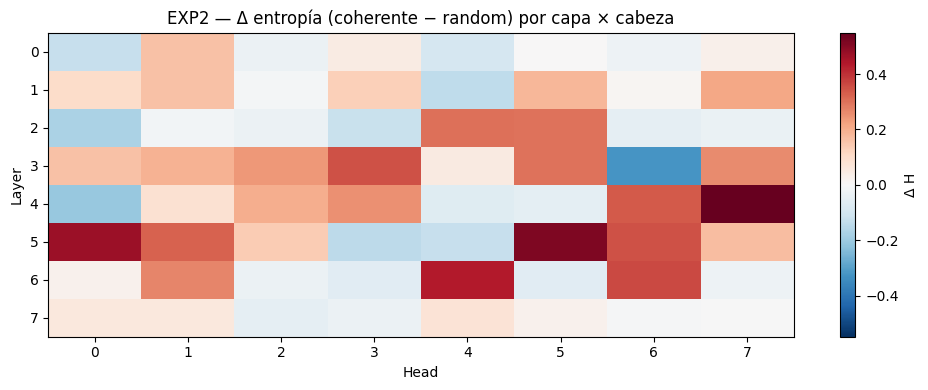

In [ ]:
#  Heatmap Δ (sense − random)  
sense_stack = stack_metric(sense_metrics, "A_attn_entropy")
rand_stack  = stack_metric(rand_metrics,  "A_attn_entropy")

ms = np.nanmean(sense_stack, axis=0)
mr = np.nanmean(rand_stack,  axis=0)

fig = heatmap_delta(ms, mr,
                     title="EXP2 — Δ entropía (coherente − random) por capa × cabeza",
                     label="Δ H")
plt.show()

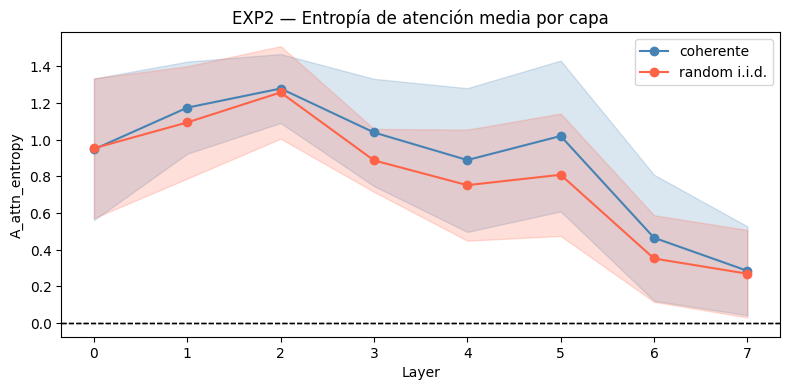

In [ ]:
#  Comparación por capa  
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_by_layer(sense_metrics, "A_attn_entropy", label="coherente",
                      color="steelblue",  ax=ax)
plot_metric_by_layer(rand_metrics,  "A_attn_entropy", label="random i.i.d.",
                      color="tomato",     ax=ax)
ax.set_title("EXP2 — Entropía de atención media por capa")
ax.legend()
plt.show()

## EXP3 — Diferenciación de estilo: wiki vs. poem

**Hipótesis**: el style embedding condiciona las cabezas de atención de forma
diferenciada. Algunas cabezas tendrán mayor entropía en modo poem (lenguaje más
libre y ambiguo) que en modo wiki (prosa factual más estructurada).


In [ ]:
TEXTS_EXP3 = [
    "La noche cae sobre la ciudad y el silencio recorre las calles como un río lento.",
    "En el jardín, las sombras se alargan y el viento escribe signos en la hierba.",
    "Las antiguas bibliotecas guardan la memoria del mundo en páginas gastadas por el tiempo.",
    "La ciencia avanza con hipótesis y pruebas, construyendo modelos que explican lo observable.",
    "El mar respira en la orilla mientras la luna tiembla sobre la espuma.",
    "Las montañas recortan el horizonte y la luz de la tarde se derrama en los valles.",
    "En los mercados, las voces se mezclan con olores de fruta y especias bajo el sol.",
    "La historia de una nación se teje con guerras, acuerdos, migraciones y cultura.",
    "En la penumbra, una lámpara dibuja círculos dorados y los recuerdos vuelven despacio.",
    "El lenguaje crea mundos: nombra lo ausente, ordena lo real y sugiere lo imposible.",
]

set_seed(42)

wiki_metrics, poem_metrics = [], []
for t in TEXTS_EXP3:
    _, mw = capture_text(t, STYLE_WIKI, MAX_LEN)
    _, mp = capture_text(t, STYLE_POEM, MAX_LEN)
    wiki_metrics.append(mw)
    poem_metrics.append(mp)

print("EXP3 calculado.")

EXP3 calculado.


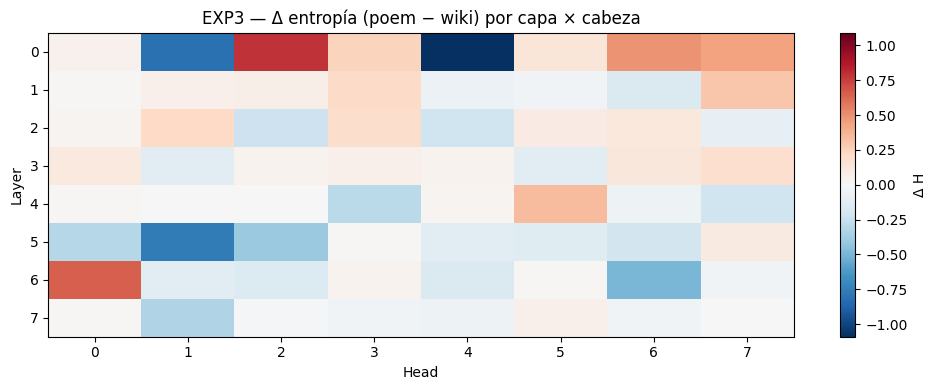

In [ ]:
#  Heatmap Δ entropía (poem − wiki) 
wiki_stack = stack_metric(wiki_metrics, "A_attn_entropy")
poem_stack = stack_metric(poem_metrics, "A_attn_entropy")

mw = np.nanmean(wiki_stack, axis=0)
mp = np.nanmean(poem_stack, axis=0)

fig = heatmap_delta(mp, mw,
                     title="EXP3 — Δ entropía (poem − wiki) por capa × cabeza",
                     label="Δ H")
plt.show()

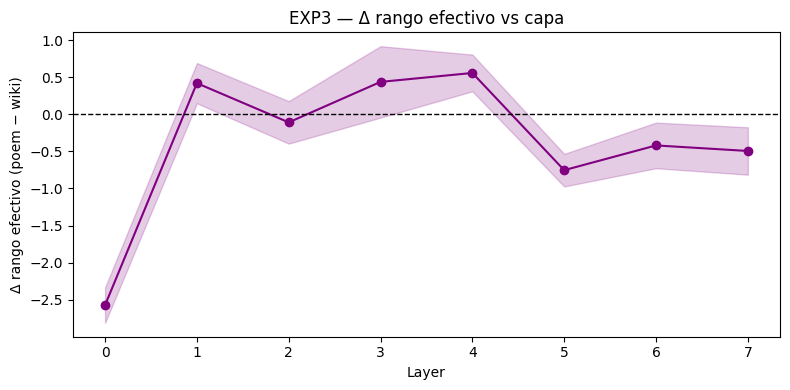

In [ ]:
#  Δ rango efectivo vs capa  
wiki_er = stack_metric(wiki_metrics, "A_effective_rank")
poem_er = stack_metric(poem_metrics, "A_effective_rank")

ER_wiki = np.nanmean(wiki_er, axis=2)   # (N, L)
ER_poem = np.nanmean(poem_er, axis=2)

delta = ER_poem - ER_wiki
mu    = np.nanmean(delta, axis=0)       # (L,)
sd    = np.nanstd(delta,  axis=0)

layers = np.arange(len(mu))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(layers, mu, marker="o", color="purple")
ax.fill_between(layers, mu - sd, mu + sd, alpha=0.2, color="purple")
ax.axhline(0.0, linestyle="--", linewidth=1, color="black")
ax.set_xlabel("Layer"); ax.set_ylabel("Δ rango efectivo (poem − wiki)")
ax.set_title("EXP3 — Δ rango efectivo vs capa")
plt.tight_layout(); plt.show()

In [ ]:
#  Top 10 cabezas más diferenciadas (wiki vs poem) 
print("Top 10 cabezas wiki vs poem (A_attn_entropy):")
print(f"{'Layer':>6} {'Head':>5} {'|Δ|':>8} {'wiki':>8} {'poem':>8}")
print("-" * 42)
for li, hi, d, aw, ap in top_sensitive_heads(wiki_metrics, poem_metrics,
                                               key="A_attn_entropy", topk=10):
    print(f"  L{li:02d}    H{hi:02d}  {d:8.4f}  {aw:8.4f}  {ap:8.4f}")

Top 10 cabezas wiki vs poem (A_attn_entropy):
 Layer  Head      |Δ|     wiki     poem
------------------------------------------
  L00    H04    1.0907    1.2497    0.1590
  L00    H01    0.8162    1.3873    0.5711
  L00    H02    0.7918    0.5930    1.3848
  L05    H01    0.7598    1.3458    0.5860
  L06    H00    0.6488    0.1135    0.7623
  L06    H06    0.4987    0.5267    0.0280
  L00    H06    0.4861    0.5924    1.0784
  L00    H07    0.4406    0.3139    0.7545
  L05    H02    0.4040    1.5605    1.1565
  L04    H05    0.3477    1.2077    1.5555


## 4. Guardado de resultados

In [ ]:
from pathlib import Path
RESULTS_DIR = Path("resultados_espectral_custom_gpt")
RESULTS_DIR.mkdir(exist_ok=True)

# Guardar una captura de ejemplo
run_example, metrics_example = capture_text(
    "El lenguaje crea mundos: nombra lo ausente.", STYLE_WIKI
)
save_run(run_example,       RESULTS_DIR / "example_run.npz")

save_metrics(metrics_example, RESULTS_DIR / "example_metrics.json")

# Verificar round-trip
run2 = load_run(RESULTS_DIR / "example_run.npz")
print(f"Round-trip OK: {run2.n_layers} capas, seq_len={run2.seq_len}")
print(f"Ficheros guardados en {RESULTS_DIR.resolve()}")

Round-trip OK: 8 capas, seq_len=12
Ficheros guardados en C:\Users\Carolina\Desktop\uni\quinto\tfg\INSO\paquete\paquetePython\experiments\notebooks\resultados_espectral_custom_gpt


## 5. Resumen visual comparativo

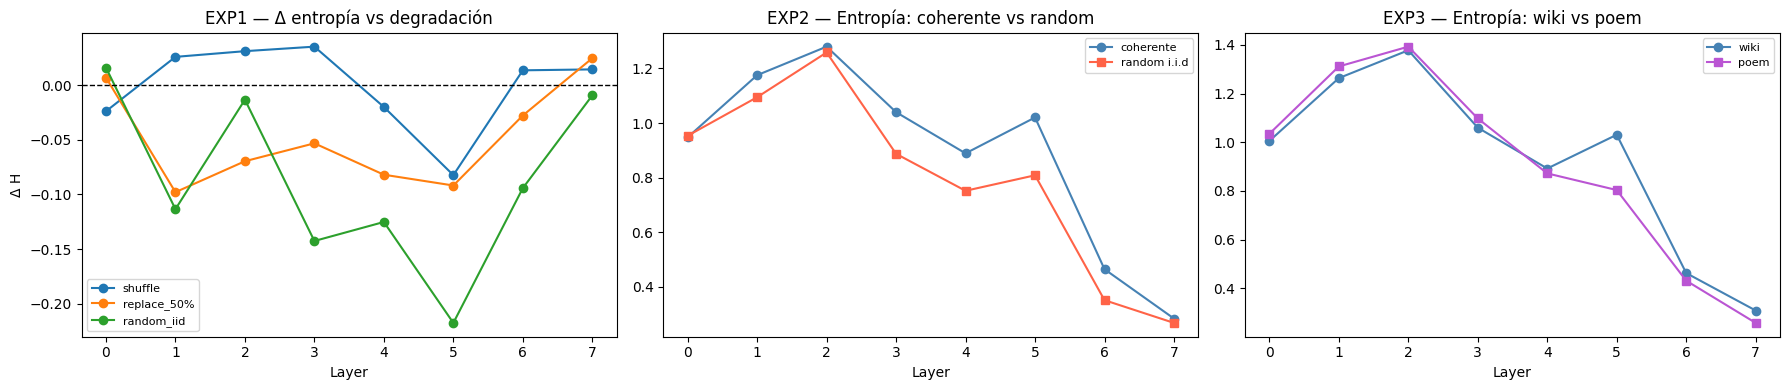

Guardado: resultados_espectral_custom_gpt/resumen_experimentos.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# EXP1: entropía de las variantes vs clean (solo random_iid)
for cond in ["shuffle", "replace_50%", "random_iid"]:
    s_c = stack_metric(per_cond["clean"], "A_attn_entropy")
    s_v = stack_metric(per_cond[cond],    "A_attn_entropy")
    mu_c = np.nanmean(s_c, axis=(0,2))
    mu_v = np.nanmean(s_v, axis=(0,2))
    axes[0].plot(np.arange(len(mu_c)), mu_v - mu_c, marker="o", label=cond)
axes[0].axhline(0, linestyle="--", linewidth=1, color="black")
axes[0].set_title("EXP1 — Δ entropía vs degradación"); axes[0].legend(fontsize=8)
axes[0].set_xlabel("Layer"); axes[0].set_ylabel("Δ H")

# EXP2: sense vs random por capa
ms_mean = np.nanmean(stack_metric(sense_metrics, "A_attn_entropy"), axis=(0,2))
mr_mean = np.nanmean(stack_metric(rand_metrics,  "A_attn_entropy"), axis=(0,2))
layers  = np.arange(len(ms_mean))
axes[1].plot(layers, ms_mean, marker="o", label="coherente",    color="steelblue")
axes[1].plot(layers, mr_mean, marker="s", label="random i.i.d", color="tomato")
axes[1].set_title("EXP2 — Entropía: coherente vs random")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Layer")

# EXP3: wiki vs poem por capa
mw_mean = np.nanmean(stack_metric(wiki_metrics, "A_attn_entropy"), axis=(0,2))
mp_mean = np.nanmean(stack_metric(poem_metrics, "A_attn_entropy"), axis=(0,2))
axes[2].plot(layers, mw_mean, marker="o", label="wiki", color="steelblue")
axes[2].plot(layers, mp_mean, marker="s", label="poem", color="mediumorchid")
axes[2].set_title("EXP3 — Entropía: wiki vs poem")
axes[2].legend(fontsize=8); axes[2].set_xlabel("Layer")

plt.tight_layout()
plt.savefig("resultados_espectral_custom_gpt/resumen_experimentos.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardado: resultados_espectral_custom_gpt/resumen_experimentos.png")